In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

## 相关性分析

分析连续变量之间的线性相关程度的强弱

图示初判 / Pearson相关系数（皮尔逊相关系数） / Sperman秩相关系数（斯皮尔曼相关系数）

#### ( 1 )变量之间的线性相关性


In [3]:
# 创建三个数据：data1为0-100的随机数并从小到大排列，data2为0-50的随机数并从小到大排列，data3为0-500的随机数并从大到小排列，
data1 = pd.Series(np.random.rand(50)*100).sort_values()
data2 = pd.Series(np.random.rand(50)*50).sort_values()
data3 = pd.Series(np.random.rand(50)*500).sort_values(ascending = False)

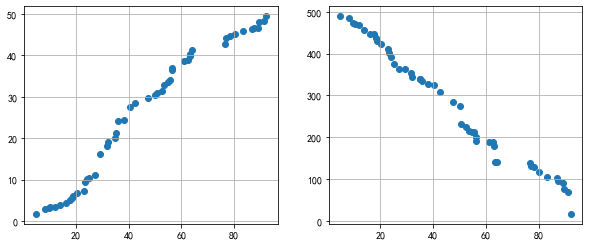

In [4]:
# 正线性相关
fig = plt.figure(figsize = (10,4))
ax1 = fig.add_subplot(1,2,1)
ax1.scatter(data1, data2)
plt.grid()

# 负线性相关
ax2 = fig.add_subplot(1,2,2)
ax2.scatter(data1, data3)
plt.grid()

### （2）散点图矩阵初判多变量间关系


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001AA245AFB88>,
      dtype=object)

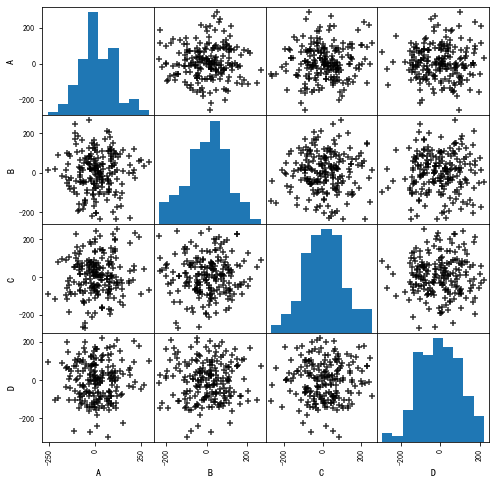

In [3]:
data = pd.DataFrame(np.random.randn(200,4)*100, columns = ['A','B','C','D'])
pd.plotting.scatter_matrix(data,figsize=(8,8),#注意Pandas中的用法与之前不同
                  c = 'k',
                 marker = '+',
                 diagonal='hist',
                 alpha = 0.8,
                 range_padding=0.1)

### Pearson相关系数


In [12]:
from scipy import stats
# scipy包是一个高级的科学计算库，它和Numpy联系很密切，Scipy一般都是操控Numpy数组来进行科学计算

In [9]:
# 创建样本数据
data1 = pd.Series(np.random.rand(100)*100).sort_values()
data2 = pd.Series(np.random.rand(100)*50).sort_values()
data = pd.DataFrame({'value1':data1.values,
                     'value2':data2.values})
data.head()

,value1,value2
0,3.017165,0.831341
1,4.827855,1.560902
2,5.090955,1.585754
3,6.111001,1.744688
4,6.750269,1.838594


In [13]:
# 正态性检验 → pvalue >0.05
u1,u2 = data['value1'].mean(),data['value2'].mean()  # 计算均值
std1,std2 = data['value1'].std(),data['value2'].std()  # 计算标准差
print('value1正态性检验：\n',stats.kstest(data['value1'], 'norm', (u1, std1)))
print('value2正态性检验：\n',stats.kstest(data['value2'], 'norm', (u2, std2)))

value1正态性检验：
 KstestResult(statistic=0.07695817148280898, pvalue=0.5818010687741536)
value2正态性检验：
 KstestResult(statistic=0.1263662525965411, pvalue=0.0750667073661036)


In [14]:
# 制作Pearson相关系数求值表
data['(x-u1)*(y-u2)'] = (data['value1'] - u1) * (data['value2'] - u2)
data['(x-u1)**2'] = (data['value1'] - u1)**2
data['(y-u2)**2'] = (data['value2'] - u2)**2
print(data.head())

     value1    value2  (x-u1)*(y-u2)    (x-u1)**2   (y-u2)**2
0  3.017165  0.831341    1201.874151  2212.373194  652.919444
1  4.827855  1.560902    1122.612334  2045.317046  616.167775
2  5.090955  1.585754    1114.964067  2021.588740  614.934604
3  6.111001  1.744688    1082.685238  1930.902530  607.077419
4  6.750269  1.838594    1062.867966  1875.129673  602.458768


In [15]:
 # |r| > 0.8 → 高度线性相关
r = data['(x-u1)*(y-u2)'].sum() / (np.sqrt(data['(x-u1)**2'].sum() * data['(y-u2)**2'].sum()))
print('Pearson相关系数为：%.4f' % r)

Pearson相关系数为：0.9856


In [16]:
# Pearson相关系数 - 算法

# 创建样本数据
data1 = pd.Series(np.random.rand(100)*100).sort_values()
data2 = pd.Series(np.random.rand(100)*50).sort_values()
data = pd.DataFrame({'value1':data1.values,
                     'value2':data2.values})
print(data.head())
print('------')

# pandas相关性方法：data.corr(method='pearson', min_periods=1) → 直接给出数据字段的相关系数矩阵
# method默认pearson
data.corr()


     value1    value2
0  1.919179  0.044841
1  3.972140  0.227457
2  4.442989  0.280995
3  5.531358  1.961970
4  8.576858  2.059302
------


,value1,value2
value1,1.000000,0.990529
value2,0.990529,1.000000


### Sperman秩相关系数

In [18]:
# 创建样本数据
data = pd.DataFrame({'智商':[106,86,100,101,99,103,97,113,112,110],
                    '每周看电视小时数':[7,0,27,50,28,29,20,12,6,17]})
print(data)



    智商  每周看电视小时数
0  106         7
1   86         0
2  100        27
3  101        50
4   99        28
5  103        29
6   97        20
7  113        12
8  112         6
9  110        17


In [19]:
# “智商”、“每周看电视小时数”重新按照从小到大排序，并设定秩次index
data.sort_values('智商', inplace=True)
data['range1'] = np.arange(1,len(data)+1)
data.sort_values('每周看电视小时数', inplace=True)
data['range2'] = np.arange(1,len(data)+1)
print(data)

    智商  每周看电视小时数  range1  range2
1   86         0       1       1
8  112         6       9       2
0  106         7       7       3
7  113        12      10       4
9  110        17       8       5
6   97        20       2       6
2  100        27       4       7
4   99        28       3       8
5  103        29       6       9
3  101        50       5      10


In [20]:
# 求出di，di2
data['d'] = data['range1'] - data['range2']
data['d2'] = data['d']**2
print(data)

    智商  每周看电视小时数  range1  range2  d  d2
1   86         0       1       1  0   0
8  112         6       9       2  7  49
0  106         7       7       3  4  16
7  113        12      10       4  6  36
9  110        17       8       5  3   9
6   97        20       2       6 -4  16
2  100        27       4       7 -3   9
4   99        28       3       8 -5  25
5  103        29       6       9 -3   9
3  101        50       5      10 -5  25


In [21]:
# 求出rs
n = len(data)
rs = 1 - 6 * (data['d2'].sum()) / (n * (n**2 - 1))
print('Pearson相关系数为：%.4f' % rs)

Pearson相关系数为：-0.1758


In [22]:
# Pearson相关系数 - 算法

data = pd.DataFrame({'智商':[106,86,100,101,99,103,97,113,112,110],
                    '每周看电视小时数':[7,0,27,50,28,29,20,12,6,17]})
print(data)
print('------')
# 创建样本数据

data.corr(method='spearman')
# pandas相关性方法：data.corr(method='pearson', min_periods=1) → 直接给出数据字段的相关系数矩阵
# method默认pearson

    智商  每周看电视小时数
0  106         7
1   86         0
2  100        27
3  101        50
4   99        28
5  103        29
6   97        20
7  113        12
8  112         6
9  110        17
------


,智商,每周看电视小时数
智商,1.000000,-0.175758
每周看电视小时数,-0.175758,1.000000
